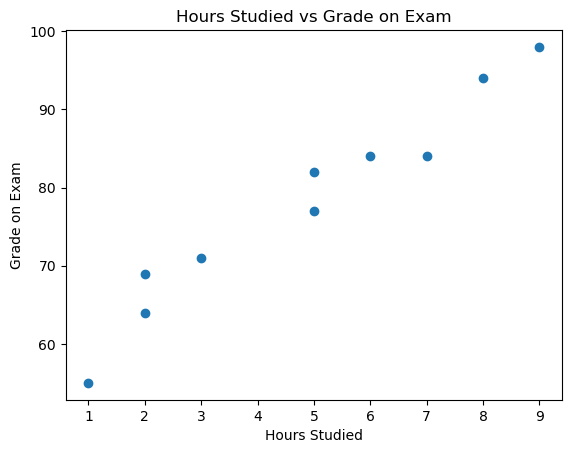

In [1]:
import numpy as np
import matplotlib.pyplot as plt

hours = np.array([2, 9, 5, 5, 3, 7, 1, 8, 6, 2], dtype=float)
grades = np.array([69, 98, 82, 77, 71, 84, 55, 94, 84, 64], dtype=float)

plt.scatter(hours, grades)
plt.xlabel("Hours Studied")
plt.ylabel("Grade on Exam")
plt.title("Hours Studied vs Grade on Exam")
plt.show()

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('../data/regression/test.csv')
df.head()

,Hours Studied,Grade on Exam
0,2,69
1,9,98
2,5,82
3,5,77
4,3,71


In [4]:
x = hours
y = grades

x_mean = x.mean()
y_mean = y.mean()

In [5]:
x_mean

np.float64(4.8)

In [6]:
y_mean

np.float64(77.8)

In [7]:
beta1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
beta0 = y_mean - beta1 * x_mean

print(f"Mean of X: {x_mean:.2f}")
print(f"Mean of Y: {y_mean:.2f}")
print(f"Intercept (β0): {beta0:.4f}")
print(f"Slope (β1): {beta1:.4f}")
print(f"Fitted line: y_hat = {beta0:.2f} + {beta1:.2f}x")

Mean of X: 4.80
Mean of Y: 77.80
Intercept (β0): 55.0355
Slope (β1): 4.7426
Fitted line: y_hat = 55.04 + 4.74x


$$Y^h = \beta_0 + \beta_1 X$$

In [8]:
X = 10

Y_hat = beta0 + beta1*X
print(f'{X} hours of work results {Y_hat}')

10 hours of work results 102.46153846153845


In [9]:
df.sort_values(by='Hours Studied')

,Hours Studied,Grade on Exam
6,1,55
0,2,69
9,2,64
4,3,71
3,5,77
2,5,82
8,6,84
5,7,84
7,8,94
1,9,98


In [10]:
new_hours = 4
predicted_grade = beta0 + beta1 * new_hours

print(f"Predicted grade for {new_hours} hours: {predicted_grade:.2f}")

Predicted grade for 4 hours: 74.01


In [11]:
#pip install -U scikit-learn

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
X = hours.reshape(-1, 1)
y = grades

hours_model = LinearRegression()
hours_model.fit(X, y)

print(f"Intercept: {hours_model.intercept_:.4f}")
print(f"Slope: {hours_model.coef_[0]:.4f}")

Intercept: 55.0355
Slope: 4.7426


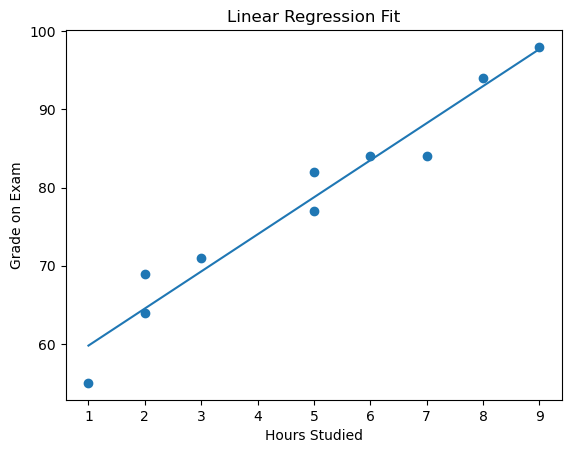

In [14]:
x_line = np.linspace(hours.min(), hours.max(), 100).reshape(-1, 1)
y_line = hours_model.predict(x_line)

plt.scatter(hours, grades)
plt.plot(x_line, y_line)
plt.title("Linear Regression Fit")
plt.xlabel("Hours Studied")
plt.ylabel("Grade on Exam")
plt.show()

In [15]:
y_pred = hours_model.predict(X)
residuals = y - y_pred

ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)

r2 = 1 - (ss_res / ss_tot)
rmse = np.sqrt(np.mean(residuals ** 2))

print(f"SS_res: {ss_res:.4f}")
print(f"SS_tot: {ss_tot:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

SS_res: 79.1213
SS_tot: 1599.6000
R-squared: 0.9505
RMSE: 2.8129


In [16]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
r2_sklearn = r2_score(y, y_pred)
rmse_sklearn = np.sqrt(mean_squared_error(y, y_pred))

In [17]:
print(f"R-squared (sklearn): {r2_sklearn:.4f}")
print(f"RMSE (sklearn): {rmse_sklearn:.4f}")

R-squared (sklearn): 0.9505
RMSE (sklearn): 2.8129


In [18]:
import pandas as pd

ads = pd.read_csv('../data/regression/advertising_and_sales.csv')
ads.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


In [19]:
ads.shape

(4546, 5)

In [20]:
ads.describe()

,tv,radio,social_media,sales
count,4546.000000,4546.000000,4546.000000,4546.000000
mean,54062.912451,18157.533110,3323.472829,192413.332112
std,26104.941838,9663.259642,2211.253915,93019.873216
min,10000.000000,0.680000,0.030000,31199.410000
25%,32000.000000,10555.355000,1530.822500,112434.610000
50%,53000.000000,17859.515000,3055.565000,188963.680000
75%,77000.000000,25640.605000,4804.922500,272324.240000
max,100000.000000,48871.160000,13981.660000,364079.750000


In [21]:
from sklearn.linear_model import LinearRegression

channels = ['tv', 'radio', 'social_media']

from utils import rsquared

for channel in channels:

    X = ads[[channel]]
    y = ads['sales']

    model = LinearRegression()
    model.fit(X,y)

    y_hat = model.predict(X)
    r2 = rsquared(y,y_hat)
    rmse = np.sqrt(np.mean((y-y_hat)**2))

    print(f'Intercept {channel}: {model.intercept_:2f}')
    print(f'Coef {channel}: {model.coef_[0]:f}')
    print(f'R_Squared {channel}: {r2}')
    print(f'RMSE {channel}: {rmse}')
    print(45*'-')


Intercept tv: -132.492506
Coef tv: 3.561514
R_Squared tv: 0.9989949845239908
RMSE tv: 2948.589712935139
---------------------------------------------
Intercept radio: 40586.800679
Coef radio: 8.361628
R_Squared radio: 0.7545316512195284
RMSE radio: 46081.40604818036
---------------------------------------------
Intercept social_media: 118672.571739
Coef social_media: 22.187863
R_Squared social_media: 0.2781997280979549
RMSE social_media: 79019.9029555142
---------------------------------------------


$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2$$

In [22]:
X.iloc[0]

social_media    2907.98
Name: 0, dtype: float64

In [23]:
def predict(n):
    y_hat = model.intercept_ + model.coef_*X.iloc[n]
    return y_hat

In [24]:
predict(2)

social_media    183314.914174
Name: 2, dtype: float64

In [25]:
model.predict(X)

array([183194.43407729, 172135.78119524, 183314.9141743 , ...,
       231746.13814231, 161736.32972793, 230644.7326146 ], shape=(4546,))

In [26]:
x_line

array([[1.        ],
       [1.08080808],
       [1.16161616],
       [1.24242424],
       [1.32323232],
       [1.4040404 ],
       [1.48484848],
       [1.56565657],
       [1.64646465],
       [1.72727273],
       [1.80808081],
       [1.88888889],
       [1.96969697],
       [2.05050505],
       [2.13131313],
       [2.21212121],
       [2.29292929],
       [2.37373737],
       [2.45454545],
       [2.53535354],
       [2.61616162],
       [2.6969697 ],
       [2.77777778],
       [2.85858586],
       [2.93939394],
       [3.02020202],
       [3.1010101 ],
       [3.18181818],
       [3.26262626],
       [3.34343434],
       [3.42424242],
       [3.50505051],
       [3.58585859],
       [3.66666667],
       [3.74747475],
       [3.82828283],
       [3.90909091],
       [3.98989899],
       [4.07070707],
       [4.15151515],
       [4.23232323],
       [4.31313131],
       [4.39393939],
       [4.47474747],
       [4.55555556],
       [4.63636364],
       [4.71717172],
       [4.797

In [27]:
corr = ads[['tv', 'radio', 'social_media', 'sales']].corr()
corr

,tv,radio,social_media,sales
tv,1.000000,0.869158,0.527687,0.999497
radio,0.869158,1.000000,0.606338,0.868638
social_media,0.527687,0.606338,1.000000,0.527446
sales,0.999497,0.868638,0.527446,1.000000


In [28]:
import plotly.express as px

fig = px.imshow(corr)
fig.show()

c:\Users\Ani\miniconda3\envs\aca\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


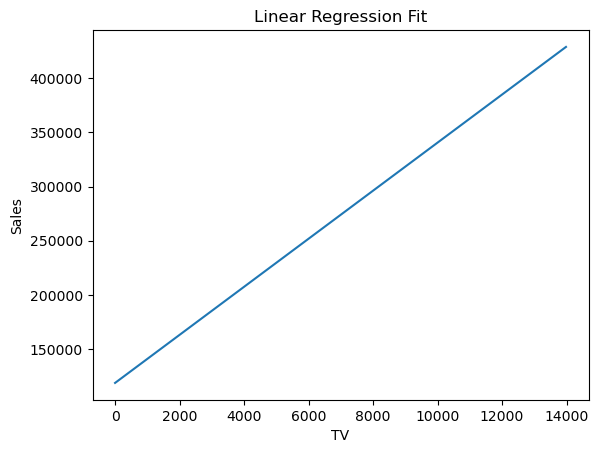

In [29]:
x_line = np.linspace(X.min(), X.max(), 2000).reshape(-1, 1)
y_line = model.predict(x_line)

import matplotlib.pyplot as plt

#plt.scatter(X, y)
plt.plot(x_line, y_line)
plt.title("Linear Regression Fit")
plt.xlabel("TV")
plt.ylabel("Sales")
plt.show()

In [30]:
tv_new_budget = [[120000]]
tv_new_budget

[[120000]]

In [31]:
model.predict(tv_new_budget)

c:\Users\Ani\miniconda3\envs\aca\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2781216.15201795])

# Multiple Linear Regression

In [32]:
X = ads[['tv', 'radio', 'social_media']]
y = ads['sales']

In [33]:
model = LinearRegression()
model.fit(X,y)
y_hat = model.predict(X)
y_hat

array([ 56855.51571432,  46154.7257576 , 145882.77851125, ...,
       156565.78405758, 252748.49571829, 149455.61837128], shape=(4546,))

In [34]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

In [35]:
r2 = r2_score(y_true = y, y_pred=y_hat)

In [36]:
rmse = root_mean_squared_error(y_true=y, y_pred=y_hat)

In [37]:
print(f"RMSE: {rmse}")
print(f"R_Squared: {r2}")


RMSE: 2948.5350308251286
R_Squared: 0.9989950218000194


In [38]:
model.intercept_

np.float64(-133.96296784211881)

In [39]:
rsquared(y, y_hat)

np.float64(0.9989950218000194)

In [40]:
from utils import rmse
rmse(y, y_hat)

np.float64(2948.5350308251286)

In [41]:
model.coef_

array([ 3.56256963, -0.00397038,  0.00496396])

In [42]:
ads.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


In [43]:
ads["influencer"] = pd.Categorical(
    ads["influencer"],
    categories=["Mega", "Macro", "Micro", "Nano"]

)

4,3,2,1

(4, 3, 2, 1)

In [44]:
ads.dtypes

tv               float64
radio            float64
social_media     float64
influencer      category
sales            float64
dtype: object

In [45]:
X = pd.get_dummies(ads["influencer"],
               drop_first=True,
               dtype= int)

In [46]:
model = LinearRegression()

model.fit(X,y)
model.coef_

array([5653.24247589, 1165.46236178, 1295.91918954])

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3$$

# Time Series

In [47]:
import glob
import os

In [48]:
import pandas as pd
from os.path import join
PATH = '../data/regression/time_series'

In [49]:
file_full_names = glob.glob(join(PATH, '*.csv'))
file_full_names

['../data/regression/time_series\\gold_prices_2022_2023.csv',
 '../data/regression/time_series\\gold_prices_2023_2024.csv',
 '../data/regression/time_series\\gold_prices_2024_2025.csv',
 '../data/regression/time_series\\gold_prices_2025_2026.csv']

In [50]:
base_name = [os.path.basename(i).split(".")[0] for i in file_full_names]
base_name

['gold_prices_2022_2023',
 'gold_prices_2023_2024',
 'gold_prices_2024_2025',
 'gold_prices_2025_2026']

In [94]:
file_full_names[0:3]

['../data/regression/time_series\\gold_prices_2022_2023.csv',
 '../data/regression/time_series\\gold_prices_2023_2024.csv',
 '../data/regression/time_series\\gold_prices_2024_2025.csv']

In [106]:
file_full_names[3]

'../data/regression/time_series\\gold_prices_2025_2026.csv'

In [107]:
dfs = [pd.read_csv(i, parse_dates=['Date']) for i in file_full_names[0:3]]

ts_combined_2022_2025 = pd.concat(dfs) #up to 2026
ts_combined_2025_2026 = pd.read_csv(file_full_names[3], parse_dates=['Date']) #from 2025_2026

In [108]:
print(ts_combined_2022_2025.dtypes)
print(100*"-")
print(ts_combined_2025_2026.dtypes)

Date     datetime64[us]
Open                str
High                str
Low                 str
Close               str
dtype: object
----------------------------------------------------------------------------------------------------
Date     datetime64[us]
Open                str
High                str
Low                 str
Close               str
dtype: object


In [109]:
ts_combined_2022_2025["Close"] = (
    ts_combined_2022_2025["Close"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

ts_combined_2022_2025["Close"] = pd.to_numeric(ts_combined_2022_2025["Close"], errors="coerce")

In [110]:
ts_combined_2025_2026["Close"] = (
    ts_combined_2025_2026["Close"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

ts_combined_2025_2026["Close"] = pd.to_numeric(ts_combined_2025_2026["Close"], errors="coerce")

In [111]:
ts_combined_2022_2025 = ts_combined_2022_2025.sort_values(by='Date')

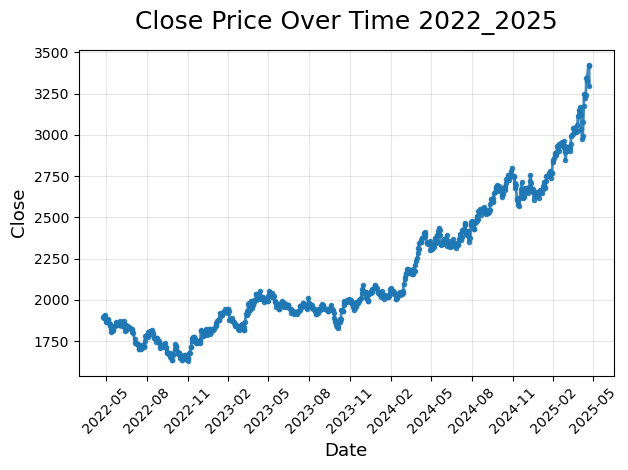

In [113]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator


plt.plot(
    ts_combined_2022_2025["Date"],
    ts_combined_2022_2025["Close"],
    linewidth=2,
    marker="o",
    markersize=3,
    alpha=0.85
)

plt.title("Close Price Over Time 2022_2025", fontsize=18, pad=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Close", fontsize=13)

# Improve x-axis date formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Reduce number of y-axis labels
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=8))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

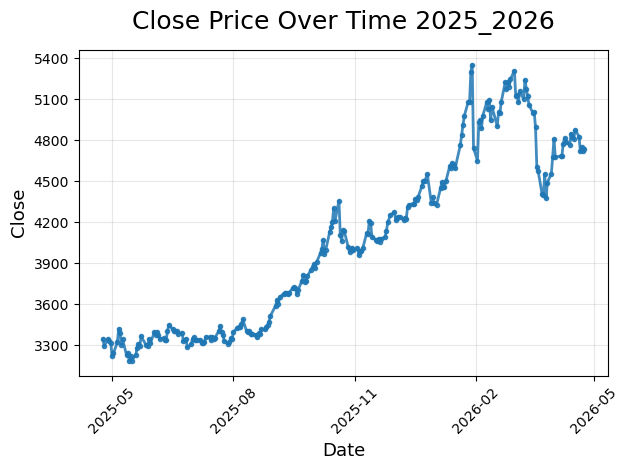

In [114]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator


plt.plot(
    ts_combined_2025_2026["Date"],
    ts_combined_2025_2026["Close"],
    linewidth=2,
    marker="o",
    markersize=3,
    alpha=0.85
)

plt.title("Close Price Over Time 2025_2026", fontsize=18, pad=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Close", fontsize=13)

# Improve x-axis date formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Reduce number of y-axis labels
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=8))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [118]:
ts_combined_2022_2025["time_index"] = np.arange(1, len(ts_combined_2022_2025) + 1)
ts_combined_2022_2025.tail() #next should be stared from 755

,Date,Open,High,Low,Close,time_index
4,2025-04-16,"3,248.40","3,358.40","3,245.20",3346.4,750
3,2025-04-17,"3,357.50","3,371.90","3,296.40",3328.4,751
2,2025-04-21,"3,347.00","3,442.30","3,344.00",3425.3,752
1,2025-04-22,"3,435.10","3,509.90","3,379.10",3419.4,753
0,2025-04-23,"3,367.70","3,396.00","3,270.80",3294.1,754


In [149]:
X_time = ts_combined_2022_2025[["time_index"]]
y_time = ts_combined_2022_2025["Close"]

In [150]:
trend_model = LinearRegression()
trend_model.fit(X_time, y_time)

trend_pred = trend_model.predict(X_time)

trend_r2 = r2_score(y_time, trend_pred)
trend_rmse = root_mean_squared_error(y_time, trend_pred)

In [151]:
print(f"Intercept: {trend_model.intercept_:.2f}")
print(f"Slope: {trend_model.coef_[0]:.4f}")
print(f"R-squared: {trend_r2:.4f}")
print(f"RMSE: {trend_rmse:.4f}")

Intercept: 1533.84
Slope: 1.6701
R-squared: 0.8454
RMSE: 155.4725


In [152]:
ts_combined_2025_2026["time_index"] = np.arange(start=755, stop=len(ts_combined_2025_2026) + 1+754, step=1)
ts_combined_2025_2026.head()


,Date,Open,High,Low,Close,time_index
0,2026-04-24,"4,715.60","4,757.10","4,672.20",4740.9,755
1,2026-04-23,"4,759.20","4,771.30","4,680.10",4724.0,756
2,2026-04-22,"4,738.70","4,790.80","4,733.10",4753.0,757
3,2026-04-21,"4,842.40","4,854.80","4,685.80",4719.6,758
4,2026-04-20,"4,811.80","4,847.90","4,748.00",4828.8,759


In [153]:
ts_combined_2025_2026.tail()

,Date,Open,High,Low,Close,time_index
249,2025-04-30,"3,324.50","3,337.60","3,275.60",3319.1,1004
250,2025-04-29,"3,354.90","3,359.30","3,309.20",3333.6,1005
251,2025-04-28,"3,336.50","3,363.80","3,278.00",3347.7,1006
252,2025-04-25,"3,362.00","3,384.10","3,274.80",3298.4,1007
253,2025-04-24,"3,301.80","3,377.00","3,301.30",3348.6,1008


In [154]:
#Predictting the Future
y_hat = trend_model.predict(ts_combined_2025_2026[['time_index']])
y_actual = ts_combined_2025_2026[['Close']]
 

In [ ]:
trend_rmse_future = root_mean_squared_error(y_hat, y_actual)

print(f'RMSE on Test: {trend_rmse_future}')
print(f'RMSE on Train: {trend_rmse}')
#trend_r2 = r2_score(y_time, trend_pred)

RMSE on Test: 1291.4568330595853
RMSE on Train: 155.4724567564181


In [156]:
future = pd.DataFrame({'time_index':[1009, 1010]}).set_index('time_index')

future

""
time_index
1009
1010


In [161]:
f = trend_model.predict

In [160]:
trend_r2

0.845365693417029

In [159]:
print(f"Intercept: {trend_model.intercept_:.2f}")
print(f"Slope: {trend_model.coef_[0]:.4f}")
print(f"R-squared: {trend_r2:.4f}")
print(f"RMSE: {trend_rmse:.4f}")

Intercept: 1533.84
Slope: 1.6701
R-squared: 0.8454
RMSE: 155.4725
